In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report



In [18]:
import pandas as pd

X_train = pd.read_csv("../data/X_train_balanced.csv")
y_train = pd.read_csv("../data/y_train_balanced.csv")

X_val = pd.read_csv("../data/X_val.csv")
y_val = pd.read_csv("../data/y_val.csv")

X_test = pd.read_csv("../data/X_test.csv")
y_test = pd.read_csv("../data/y_test.csv")

In [19]:
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()
y_test = y_test.values.ravel()

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [21]:
svm = LinearSVC( class_weight="balanced", random_state=42, max_iter=5000)

svm.fit(X_train, y_train);

In [22]:
from sklearn.metrics import accuracy_score

y_val_pred = svm.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

print("Validation accuracy:", val_accuracy)

Validation accuracy: 0.731777176968172


In [23]:
y_pred = svm.predict(X_test)

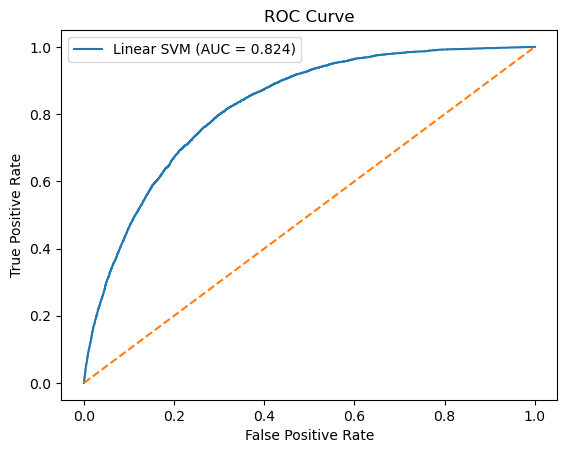

In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_scores = svm.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"Linear SVM (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [25]:
import numpy as np

print("Number predicted as no diabetes (0):", np.sum(y_pred == 0))
print("Number predicted as diabetes (1):", np.sum(y_pred == 1))

Number predicted as no diabetes (0): 24428
Number predicted as diabetes (1): 12930


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc_score = roc_auc_score(y_test, y_scores)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC AUC  :", round(auc_score, 4))

Accuracy : 0.7307
Precision: 0.3159
Recall   : 0.7705
F1-score : 0.4481
ROC AUC  : 0.824


In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[23211  8845]
 [ 1217  4085]]


In [28]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
#from hyperopt import tpe, STATUS_OK, Trials, hp, fmin, STATUS_OK, space_eval

In [29]:
C_range = np.logspace(-10, 10, 21)
print(f"The list of values for C are {C_range}")


The list of values for C are [1.e-10 1.e-09 1.e-08 1.e-07 1.e-06 1.e-05 1.e-04 1.e-03 1.e-02 1.e-01
 1.e+00 1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08 1.e+09
 1.e+10]


In [30]:
param_grid = {
    "C": C_range,
    "loss": ["hinge", "squared_hinge"],
    "penalty": ["l2"],
    "max_iter": [2000, 5000, 10000]
}
scoring = "accuracy"
kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
random_search = RandomizedSearchCV(estimator=svm,
                                   param_distributions=param_grid,
                                   n_iter=20,
                                   scoring=scoring,
                                   refit="accuracy",
                                   n_jobs=-1,
                                   cv=kfold,
                                   verbose=0)
random_result = random_search.fit(X_train, y_train)
random_result

KeyboardInterrupt: 